# MetaLore Simulator — Getting Started

**MetaLore** is a Gymnasium-compatible reinforcement learning environment for smart city wireless sensor network simulation.

### What does it simulate?

| Entity | Role |
|---|---|
| **Base Station (BS)** | Wireless access point with bandwidth and edge server with compute capacity |
| **User Equipment (UE)** | Mobile device that generates service requests |
| **Sensor** | IoT device that continuously streams context data |

### What does the agent control?

At each timestep the agent outputs **two continuous actions** in [0, 1]:

- `bw_split` — fraction of total bandwidth allocated to UEs (the rest goes to sensors)
- `comp_split` — fraction of total compute capacity allocated to UE jobs (the rest to sensor jobs)

### Job lifecycle:

```
UE generates job → TX queue in UE → wireless transmission → BS proc queue → MEC processing → done
Sensor generates job ─────────────────────────────────────────────────────------───────────→ done
```

UE jobs are only processed once a fresh sensor snapshot is available for the nearest sensor.

### Key metrics:

| Metric | Full name | Role |
|---|---|---|
| **AoRI** | Age of Request Information |  UE job end-to-end latency |
| **AoSI** | Age of Sensor Information |  sensor data staleness |

## 1. Setup & Imports

In [1]:
import sys
sys.path.insert(0, '.')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython import display as ipd

from metalore.scenarios import SingleCellEnv, MultiCellEnv
from metalore.config import default_config, small_config, large_config, mobile_sensor_config, multi_cell_config

print("MetaLore imported successfully!")

MetaLore imported successfully!


## 2. Available Configurations

MetaLore ships with five pre-built configurations. Each is a plain Python dict that you can pass directly or customise.

| Config | Scenario |
|---|---|
| `default_config` | Minimal — fast to run, good for debugging |
| `small_config` | Standard single-cell baseline |
| `large_config` | More UEs and sensors |
| `mobile_sensor_config` | Sensors that move over time |
| `multi_cell_config` | Multiple BSs |

The cell below shows their key parameters.

In [2]:
# Create environment
config = large_config()
config['environment']['seed'] = 42
config['environment']['reset_rng_episode'] = True  # reset RNG each episode for full reproducibility

# Compare environment configurations
configs = {
    'small': (SingleCellEnv, small_config()),
    'default': (SingleCellEnv, default_config()),
    'large': (SingleCellEnv, large_config()),
    'mobile_sensor': (SingleCellEnv, mobile_sensor_config()),
    'multi_cell': (MultiCellEnv, multi_cell_config()),
}

rows = []
for name, (EnvClass, config) in configs.items():
    env = EnvClass(config=config)
    env.reset()
    rows.append({
        'Config': name,
        'BSs': env.num_bs,
        'UEs': env.num_ues,
        'Sensors': env.num_sensors,
        'Width': env.width,
        'Height': env.height,
        'Max Steps': env.EP_MAX_TIME,
    })
    env.close()

config_df = pd.DataFrame(rows)
ipd.display(config_df)

,Config,BSs,UEs,Sensors,Width,Height,Max Steps
0,small,1,5,8,200.0,200.0,100
1,default,1,3,3,200.0,200.0,100
2,large,1,20,10,200.0,200.0,100
3,mobile_sensor,1,10,5,200.0,200.0,100
4,multi_cell,3,15,20,200.0,200.0,100


## 3. Running an Episode

MetaLore follows the standard [Gymnasium](https://gymnasium.farama.org/) API:

```python
obs, info                 = env.reset()                              # start a new episode
obs, r, term, trunc, info = env.step([bw_split, comp_split])         # advance one timestep
```

In [3]:
# Create environment
env = SingleCellEnv(config=small_config())
obs, info = env.reset()

print("="*60)
print("ENVIRONMENT SETUP")
print("="*60)
print(f"Base Stations: {env.num_bs}")
print(f"User Equipment: {env.num_ues}")
print(f"Sensors: {env.num_sensors}")
print(f"Area: {env.width} x {env.height}")
print(f"Max Steps: {env.EP_MAX_TIME}")
print()
print("="*60)
print("RL INTERFACE")
print("="*60)
print(f"Action Space: {env.action_space}")
print(f"Observation Space: {env.observation_space}")
print(f"Initial Observation Shape: {obs.shape}")

ENVIRONMENT SETUP
Base Stations: 1
User Equipment: 5
Sensors: 8
Area: 200.0 x 200.0
Max Steps: 100

RL INTERFACE
Action Space: Box(0.0, 1.0, (2,), float32)
Observation Space: Box(0.0, 10000.0, (2,), float32)
Initial Observation Shape: (2,)


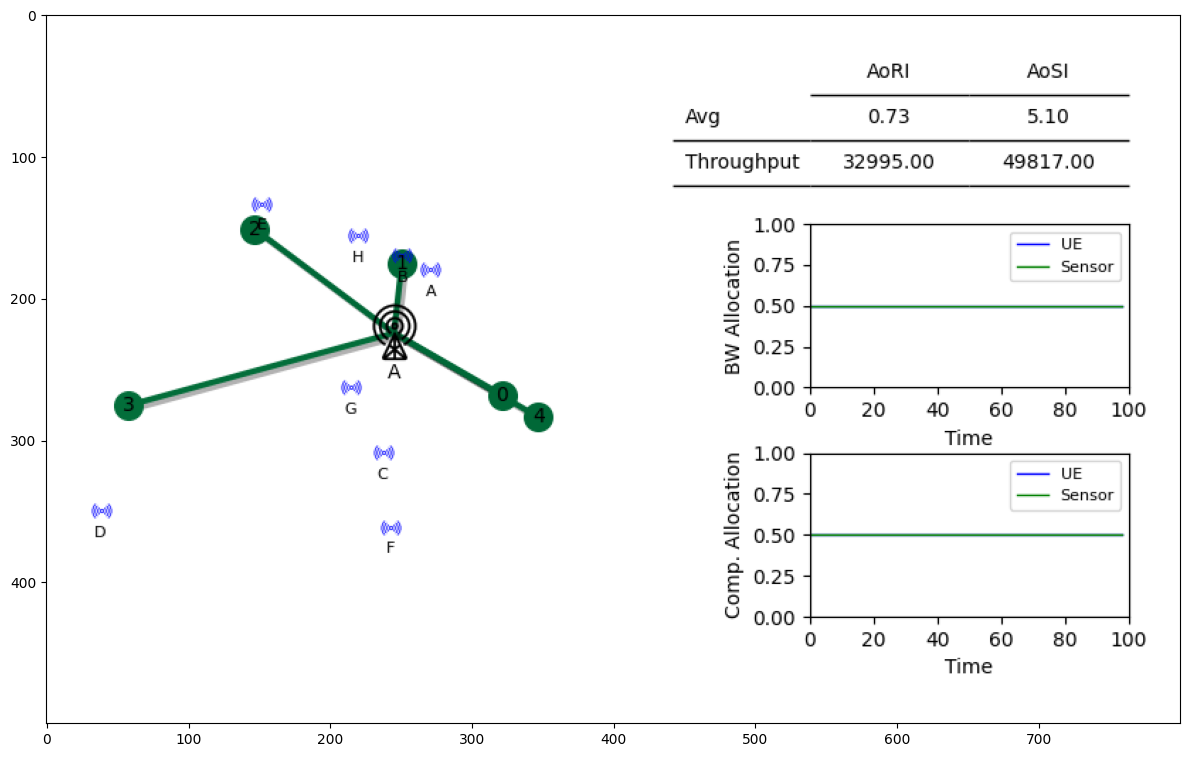

Episode ended at step 100

Steps completed : 100
Total reward    : 2285.1397


In [ ]:
# Run a full episode with random actions
N_STEPS =  100

rewards = []
for step in range(N_STEPS):
    #action = env.action_space.sample()   # random policy
    action = [0.5, 0.5]                   # fixed equal-split policy
    obs, reward, terminated, truncated, info = env.step(action)
    rewards.append(reward)

    if terminated or truncated:
        print(f"Episode ended at step {step+1}")
        break
    
    # Animate during simulation
    ipd.clear_output(wait=True)
    fig, ax = plt.subplots(figsize=(12, 8))
    ax.imshow(env.render())
    plt.tight_layout()
    plt.show()
    plt.close()

print()
print(f"Steps completed : {len(rewards)}")
print(f"Total reward    : {sum(rewards):.4f}")

## 4. Metrics Reference

After running an episode all data lives in `env.metrics` (a `MetricsTracker`). It is organised into **five structures** with different granularities:

| Attribute | What it holds | Keys |
|---|---|---|
| `step_totals` | One scalar per timestep, aggregated over all entities | `str → List` |
| `step_per_entity` | One value per entity per timestep | `str → {('UE'\|'SENSOR', id): List}` |
| `step_per_bs` | One value per BS per timestep — most useful for multi-cell | `str → {bs_id: List}` |
| `step_topology` | Connection-map snapshot per timestep | `str → List[dict]` |
| `ep_totals` | Episode-level scalar aggregates | `str → scalar` |
| `ep_per_entity` | Episode total per entity | `str → {('UE'\|'SENSOR', id): scalar}` |

`ep_totals` and `ep_per_entity` are populated by calling `metrics.finalize(env.job_tracker)` at the end of an episode (Section 8).

In [5]:
# Step totals — one row per timestep, aggregated over all entities
st = env.metrics.step_totals
df_totals = pd.DataFrame({k: v for k, v in st.items() if k != "observation"}).set_index("time")
print("STEP TOTALS")
ipd.display(df_totals)

STEP TOTALS


,num_active_ues,num_active_sensors,ue_tx_queue_bits,sensor_tx_queue_bits,ue_tx_queue_jobs,sensor_tx_queue_jobs,jobs_generated,jobs_transmitted,jobs_processed,bits_transmitted,...,ue_bits_transmitted,sensor_bits_transmitted,ue_cycles_processed,sensor_cycles_processed,bw_split,comp_split,reward,mean_aoi,mean_aori,mean_aosi
time,,,,,,,,,,,,,,,,,,,,,
0,5,8,25.575469,20.645664,3,1,11,7,7,776.778867,...,276.424531,500.354336,0.0,47.0,0.5,0.5,0.000000,NaN,NaN,NaN
1,5,8,76.067335,45.328825,4,3,12,9,9,877.824973,...,355.508134,522.316838,23.0,42.0,0.5,0.5,30.000000,1.000000,1.00,0.000000
2,5,8,67.830740,68.936991,3,1,12,15,11,888.628429,...,376.236595,512.391834,40.0,42.0,0.5,0.5,37.000000,1.500000,0.75,0.750000
3,5,8,135.511852,100.031473,3,3,11,9,13,756.224406,...,250.318888,505.905517,38.0,57.0,0.5,0.5,38.000000,1.750000,1.25,0.500000
4,5,8,61.434128,160.520079,2,5,11,10,10,891.589118,...,382.077724,509.511394,42.0,50.0,0.5,0.5,38.000000,1.250000,0.75,0.500000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,5,8,0.000000,3462.704977,0,50,8,9,7,506.316838,...,0.000000,506.316838,0.0,48.0,0.5,0.5,0.000000,NaN,NaN,NaN
96,5,8,0.000000,3481.388139,0,50,9,9,9,615.316838,...,89.000000,526.316838,6.0,45.0,0.5,0.5,6.561000,4.000000,0.00,4.000000
97,5,8,1.726257,3510.071300,1,50,12,11,9,917.590581,...,402.273743,515.316838,33.0,55.0,0.5,0.5,16.260106,6.333333,0.00,6.333333


## 5. Per-BS Metrics (Multi-Cell)

`step_per_bs` holds one time series per base station, keyed by `bs_id`. This is most useful when running a **MultiCellEnv**, but it also works for single-cell runs (one key per dict).

| Key | Description |
|---|---|
| `ue_connections` | Number of UEs connected to this BS |
| `sensor_connections` | Number of sensors connected to this BS |
| `ue_proc_queue_jobs` | UE jobs waiting in this BS's processing queue |
| `sensor_proc_queue_jobs` | Sensor jobs waiting in this BS's processing queue |
| `ue_proc_queue_cycles` | UE compute cycles backlogged at this BS |
| `sensor_proc_queue_cycles` | Sensor compute cycles backlogged at this BS |

In [6]:
# Per-BS metrics — one time series per base station
times = env.metrics.step_totals["time"]
for metric, bs_data in env.metrics.step_per_bs.items():
    df = pd.DataFrame(
        {f"BS {bs_id}": vals for bs_id, vals in bs_data.items()},
        index=times
    )
    df.index.name = "time"
    print(f"\n{metric}")
    ipd.display(df)


ue_connections


,BS 0
time,
0,5
1,5
2,5
3,5
4,5
...,...
95,5
96,5
97,5



sensor_connections


,BS 0
time,
0,8
1,8
2,8
3,8
4,8
...,...
95,8
96,8
97,8



ue_proc_queue_jobs


...

,BS 0
time,
0,0
1,0
2,3
3,0
4,0
...,...
95,25
96,25
97,27



ue_proc_queue_cycles


,BS 0
time,
0,0.0
1,0.0
2,6.0
3,0.0
4,0.0
...,...
95,0.0
96,0.0
97,0.0



sensor_proc_queue_cycles


,BS 0
time,
0,0.0
1,0.0
2,13.0
3,0.0
4,0.0
...,...
95,181.0
96,196.0
97,191.0


## 6. Detailed Metrics Tables

Raw step-by-step data for every metric. Useful for debugging or exporting to CSV.

In [7]:
# Per-entity metrics — one time series per (entity_type, entity_id)
times = env.metrics.step_totals["time"]
for metric, entity_data in env.metrics.step_per_entity.items():
    df = pd.DataFrame(
        {f"{etype} {eid}": vals for (etype, eid), vals in sorted(entity_data.items())},
        index=times
    )
    df.index.name = "time"
    print(f"\n{metric}")
    ipd.display(df)


datarate


,SENSOR 0,SENSOR 1,SENSOR 2,SENSOR 3,SENSOR 4,SENSOR 5,SENSOR 6,SENSOR 7,UE 0,UE 1,UE 2,UE 3,UE 4
time,,,,,,,,,,,,,
0,93.345766,90.301416,77.194556,47.354336,65.551181,62.411321,95.896048,82.173071,88.381980,101.678743,79.075863,95.187120,79.558668
1,93.345766,90.301416,77.194556,47.354336,65.551181,62.411321,95.896048,82.173071,88.381980,101.678743,79.075863,95.187120,79.558668
2,93.345766,90.301416,77.194556,47.354336,65.551181,62.411321,95.896048,82.173071,88.662343,102.033109,79.308822,95.208630,79.798971
3,93.345766,90.301416,77.194556,47.354336,65.551181,62.411321,95.896048,82.173071,88.944217,102.389674,79.542845,95.227954,80.040457
4,93.345766,90.301416,77.194556,47.354336,65.551181,62.411321,95.896048,82.173071,89.227618,102.748460,79.777942,95.245085,80.283139
...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,93.345766,90.301416,77.194556,47.354336,65.551181,62.411321,95.896048,82.173071,124.092732,146.299176,107.244306,88.557453,109.619872
96,93.345766,90.301416,77.194556,47.354336,65.551181,62.411321,95.896048,82.173071,124.612516,147.233115,107.635914,88.416027,110.060390
97,93.345766,90.301416,77.194556,47.354336,65.551181,62.411321,95.896048,82.173071,125.136050,148.184904,108.030111,88.273743,110.504791



tx_queue_jobs


,SENSOR 0,SENSOR 1,SENSOR 2,SENSOR 3,SENSOR 4,SENSOR 5,SENSOR 6,SENSOR 7,UE 0,UE 1,UE 2,UE 3,UE 4
time,,,,,,,,,,,,,
0,0,0,0,1,0,0,0,0,0,1,0,1,1
1,0,0,0,1,1,1,0,0,1,1,1,0,1
2,0,0,0,1,0,0,0,0,1,0,0,1,1
3,0,0,0,2,1,0,0,0,1,0,1,0,1
4,0,0,1,2,1,1,0,0,0,0,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,0,0,0,33,7,10,0,0,0,0,0,0,0
96,0,0,0,33,7,10,0,0,0,0,0,0,0
97,0,0,0,33,7,10,0,0,0,0,0,1,0



jobs_generated


...

,SENSOR 0,SENSOR 1,SENSOR 2,SENSOR 3,SENSOR 4,SENSOR 5,SENSOR 6,SENSOR 7,UE 0,UE 1,UE 2,UE 3,UE 4
time,,,,,,,,,,,,,
0,1,1,1,0,1,1,1,1,0,0,0,0,0
1,1,1,1,1,0,0,1,1,0,1,0,1,1
2,1,1,1,1,2,1,0,0,1,2,1,0,0
3,1,1,1,0,0,2,2,2,1,0,0,1,2
4,1,1,0,1,1,0,1,1,1,1,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,1,1,1,1,1,1,0,1,0,0,0,0,0
96,1,1,1,1,1,0,2,1,1,0,0,0,0
97,1,1,1,0,1,1,0,1,1,0,1,0,1



bits_transmitted


,SENSOR 0,SENSOR 1,SENSOR 2,SENSOR 3,SENSOR 4,SENSOR 5,SENSOR 6,SENSOR 7,UE 0,UE 1,UE 2,UE 3,UE 4
time,,,,,,,,,,,,,
0,76.0,51.0,71.000000,47.354336,54.000000,60.000000,82.0,59.0,0.000000,101.678743,0.000000,95.187120,79.558668
1,64.0,63.0,67.000000,47.354336,65.551181,62.411321,78.0,75.0,88.381980,101.678743,79.075863,6.812880,79.558668
2,66.0,63.0,67.000000,47.354336,62.448819,59.588679,71.0,76.0,88.662343,89.642515,22.924137,95.208630,79.798971
3,77.0,55.0,71.000000,47.354336,65.551181,58.000000,54.0,78.0,88.944217,0.000000,79.542845,1.791370,80.040457
4,64.0,54.0,77.194556,47.354336,65.551181,62.411321,64.0,75.0,47.011460,101.000000,79.777942,95.245085,59.043236
...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,73.0,65.0,65.000000,47.354336,65.551181,62.411321,68.0,60.0,0.000000,0.000000,0.000000,0.000000,0.000000
96,82.0,63.0,77.000000,47.354336,65.551181,62.411321,54.0,75.0,89.000000,0.000000,0.000000,0.000000,0.000000
97,70.0,72.0,62.000000,47.354336,65.551181,62.411321,64.0,72.0,114.000000,0.000000,97.000000,88.273743,103.000000



cycles_processed


,SENSOR 0,SENSOR 1,SENSOR 2,SENSOR 3,SENSOR 4,SENSOR 5,SENSOR 6,SENSOR 7,UE 0,UE 1,UE 2,UE 3,UE 4
time,,,,,,,,,,,,,
0,7.0,9.0,8.0,0.0,6.0,4.0,7.0,6.0,0.0,0.0,0.0,0.0,0.0
1,3.0,5.0,5.0,8.0,0.0,0.0,11.0,10.0,0.0,6.0,0.0,10.0,7.0
2,5.0,8.0,9.0,5.0,9.0,6.0,0.0,0.0,12.0,23.0,5.0,0.0,0.0
3,8.0,4.0,2.0,0.0,0.0,17.0,10.0,16.0,4.0,0.0,0.0,10.0,24.0
4,9.0,15.0,0.0,8.0,4.0,0.0,8.0,6.0,7.0,10.0,18.0,0.0,7.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,7.0,5.0,7.0,9.0,6.0,9.0,0.0,5.0,0.0,0.0,0.0,0.0,0.0
96,5.0,7.0,7.0,3.0,8.0,0.0,8.0,7.0,6.0,0.0,0.0,0.0,0.0
97,7.0,8.0,8.0,0.0,10.0,12.0,0.0,10.0,10.0,0.0,9.0,0.0,14.0


## 7. Episode Summary

In [8]:
# Finalize episode — computes ep_totals and ep_per_entity
ep_summary = env.metrics.finalize(env.job_tracker)

# Episode totals
print("="*60)
print("EPISODE TOTALS")
print("="*60)
for k, v in ep_summary.items():
    if k != "per_entity":
        print(f"  {k}: {v}")

# Per-entity episode totals
print()
print("="*60)
print("EPISODE PER-ENTITY TOTALS")
print("="*60)
for field, entity_vals in ep_summary["per_entity"].items():
    df = pd.DataFrame.from_dict(entity_vals, orient='index', columns=[field])
    df.index = [f"{etype} {eid}" for (etype, eid) in df.index]
    print(f"\n  {field}")
    ipd.display(df)

# Full job lifecycle log (completed jobs only)
print()
print("="*60)
print("JOB LIFECYCLE LOG (completed jobs)")
print("="*60)
job_df = env.job_tracker.to_dataframe()
if not job_df.empty:
    ipd.display(job_df)
    env.job_tracker.save_log("logs/jobs.csv")
    print("Saved: logs/jobs.csv")

# All generated jobs via monitor
print()
print("="*60)
print("ALL GENERATED JOBS (monitor)")
print("="*60)
monitor_df = env.monitor.dataframe()
ipd.display(monitor_df)

EPISODE TOTALS
  jobs_generated: 1132
  jobs_transmitted: 1079
  jobs_processed: 1051
  bits_transmitted: 85630.54905280517
  cycles_processed: 8393.0
  job_completion_rate: 0.9284452296819788
  total_reward: 2285.1397277118535
  mean_aoi: 5.81570996978852
  mean_aori: 0.7280966767371602
  mean_aosi: 5.087613293051359

EPISODE PER-ENTITY TOTALS

  jobs_generated


,jobs_generated
UE 1,62
UE 3,70
UE 4,71
SENSOR 0,100
SENSOR 1,100
SENSOR 2,100
SENSOR 3,100
SENSOR 4,100
SENSOR 5,100
SENSOR 6,100



  jobs_transmitted


,jobs_transmitted
UE 1,62
UE 3,69
UE 4,71
SENSOR 0,100
SENSOR 1,100
SENSOR 2,100
SENSOR 3,66
SENSOR 4,93
SENSOR 5,89
SENSOR 6,100



  jobs_processed


...

,cycles_processed
UE 1,626.0
UE 3,700.0
UE 4,748.0
SENSOR 0,659.0
SENSOR 1,658.0
SENSOR 2,686.0
SENSOR 3,426.0
SENSOR 4,574.0
SENSOR 5,603.0
SENSOR 6,689.0



JOB LIFECYCLE LOG (completed jobs)


,job_id,entity_id,entity_type,data_size,compute_size,generated_at,tx_start_at,tx_end_at,proc_start_at,proc_end_at,tx_queue_wait,tx_duration,proc_queue_wait,proc_duration,nearest_sensor_id,sensor_snapshot_at,aoi,aori,aosi
0,3,0,SENSOR,76.0,7.0,0,0,0,0,0,0,0,0,0,NaN,NaN,NaN,0,NaN
1,4,1,SENSOR,51.0,9.0,0,0,0,0,0,0,0,0,0,NaN,NaN,NaN,0,NaN
2,5,2,SENSOR,71.0,8.0,0,0,0,0,0,0,0,0,0,NaN,NaN,NaN,0,NaN
3,7,4,SENSOR,54.0,6.0,0,0,0,0,0,0,0,0,0,NaN,NaN,NaN,0,NaN
4,8,5,SENSOR,60.0,4.0,0,0,0,0,0,0,0,0,0,NaN,NaN,NaN,0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1046,978,5,SENSOR,52.0,7.0,85,95,95,99,99,10,0,4,0,NaN,NaN,NaN,14,NaN
1047,1088,6,SENSOR,68.0,6.0,95,95,95,99,99,0,0,4,0,NaN,NaN,NaN,4,NaN
1048,1089,7,SENSOR,60.0,6.0,95,95,95,99,99,0,0,4,0,NaN,NaN,NaN,4,NaN
1049,1091,0,SENSOR,82.0,7.0,96,96,96,99,99,0,0,3,0,NaN,NaN,NaN,3,NaN


Saved: logs/jobs.csv

ALL GENERATED JOBS (monitor)


,job_id,entity_id,entity_type,data_size,compute_size,generated_at,is_transmitted,is_processed,tx_start_at,tx_end_at,...,proc_end_at,tx_queue_wait,tx_duration,proc_queue_wait,proc_duration,nearest_sensor_id,sensor_snapshot_at,aoi,aori,aosi
0,0,1,UE,106.0,6.0,0,True,True,0.0,1.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
1,1,3,UE,102.0,10.0,0,True,True,0.0,1.0,...,1.0,0.0,1.0,0.0,0.0,4.0,0.0,1.0,1.0,0.0
2,2,4,UE,94.0,7.0,0,True,True,0.0,1.0,...,1.0,0.0,1.0,0.0,0.0,5.0,0.0,1.0,1.0,0.0
3,3,0,SENSOR,76.0,7.0,0,True,True,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,0.0,NaN
4,4,1,SENSOR,51.0,9.0,0,True,True,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,0.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1127,1127,3,SENSOR,68.0,8.0,99,False,False,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1128,1128,4,SENSOR,75.0,6.0,99,False,False,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1129,1129,5,SENSOR,67.0,9.0,99,False,False,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1130,1130,6,SENSOR,68.0,8.0,99,True,False,99.0,99.0,...,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 8. Sensor Synchronisation & Age of Information

UE jobs are only processed once a fresh sensor snapshot is available from the nearest sensor.  
Three metrics capture how fresh that data is:

| Metric | Formula | Interpretation |
|---|---|---|
| **AoRI** | `proc_end_at − generated_at` | UE job's end-to-end latency |
| **AoSI** | `sensor_snapshot_at − generated_at` | How old the sensor data was when the UE job was born |
| **AoI** | `proc_end_at − sensor_snapshot_at` | Staleness of sensor data at processing time |

In [9]:
job_df = env.job_tracker.to_dataframe()
ue_df = job_df[job_df['entity_type'] == 'UE'].copy()

# --- AoI / AoRI / AoSI stats ---
print("="*60)
print("AGE METRICS (UE jobs)")
print("="*60)
for col, label in [('aori', 'AoRI'), ('aosi', 'AoSI'), ('aoi', 'AoI')]:
    s = ue_df[col].dropna()
    print(f"  {label:5s}  mean={s.mean():.2f}  max={s.max():.0f}  min={s.min():.0f}")

# --- Per-UE breakdown ---
print()
print("="*60)
print("PER-UE AGE METRICS")
print("="*60)
per_ue = ue_df.groupby('entity_id')[['aori', 'aosi', 'aoi']].mean().round(2)
per_ue.index = [f'UE {i}' for i in per_ue.index]
ipd.display(per_ue)

# --- Full UE job table with sensor context columns ---
print()
print("UE JOB LOG")
cols = ['job_id', 'entity_id', 'generated_at', 'proc_end_at',
        'nearest_sensor_id', 'sensor_snapshot_at', 'aori', 'aosi', 'aoi']
ipd.display(ue_df[cols].reset_index(drop=True))

AGE METRICS (UE jobs)
  AoRI   mean=0.73  max=2  min=0
  AoSI   mean=5.09  max=36  min=0
  AoI    mean=5.82  max=37  min=1

PER-UE AGE METRICS


,aori,aosi,aoi
UE 0,0.41,2.61,3.02
UE 1,0.10,1.82,1.92
UE 2,0.95,5.05,6.00
UE 3,1.01,13.65,14.67
UE 4,1.10,1.96,3.06



UE JOB LOG


,job_id,entity_id,generated_at,proc_end_at,nearest_sensor_id,sensor_snapshot_at,aori,aosi,aoi
0,0,1,0,1,0.0,0.0,1,0.0,1.0
1,1,3,0,1,4.0,0.0,1,0.0,1.0
2,2,4,0,1,5.0,0.0,1,0.0,1.0
3,11,0,1,2,5.0,0.0,1,1.0,2.0
4,12,1,1,2,0.0,1.0,1,0.0,1.0
...,...,...,...,...,...,...,...,...,...
326,1111,1,98,98,1.0,94.0,0,4.0,4.0
327,1101,3,97,98,3.0,61.0,1,36.0,37.0
328,1120,0,99,99,2.0,95.0,0,4.0,4.0
329,1121,1,99,99,1.0,95.0,0,4.0,4.0
